In [142]:
from tradepy.data.loader import load_future
from tradepy.config.config import load_config, load_symbols, load_feature_config, load_exclude_config
from tradepy.data.loader import load_specs
from tradepy.data.cleaner import add_trading_date_by_gap
from tradepy.data.resampler import resample_ohlcv, daily_ohlcv_cummulative
from tradepy.features.generate import generate_features
from tradepy.features.quality_check import data_quality_report
from tradepy.supervised.load import prepare_all
from tradepy.paths import EXCLUDE_CONFIG, SYSTEM_CONFIG
from tradepy.supervised.target import target_triple_barrier_interday
from tradepy.supervised.pretrain import filter_features
from tradepy.supervised.models import GoldLSTM_L1_Move, GoldLSTM_L2_Dir, GoldGRU_L1_Move, GoldGRU_L2_Dir, BasicLSTM_L1_Move, BasicLSTM_L2_Dir, BasicGRU_L1_Move, BasicGRU_L2_Dir, BasicLSTM_L3_Regression, BasicGRU_L3_Regression
from tradepy.supervised.train import train_walk_forward_2level, grid_search_thresholds, create_lstm_dataset
from tradepy.supervised.posttrain import evaluate_model_classification, tune_threshold_wf, save_trading_model_2level, load_trading_model_3level
from tradepy.paths import MODELS_DIR, BT_DIR

import pandas as pd

In [143]:
symbols = load_symbols()
cfg = load_config()

In [144]:
symbols

['AD',
 'BP',
 'CL',
 'EC',
 'ES',
 'GC',
 'MFXI',
 'NG',
 'NQ',
 'YM',
 'ZB',
 'ZN',
 'ZS']

In [145]:
ASSET = symbols[12]
MINUTES             = cfg['sampling_minutes']        # 240
RETURN_HORIZON_MIN  = cfg['return_horizon_min']      # 2880

In [146]:
(
    model_l1,
    model_l2,
    model_l3,
    sc_features,
    sc_l3,
    features,
    params,
    thresholds,
    df_results
) = load_trading_model_3level(
        BasicLSTM_L1_Move,
        BasicLSTM_L2_Dir,
        BasicLSTM_L3_Regression,
        path=f"{MODELS_DIR}/{ASSET.lower()}/trading_model_lstm_3level",
        device="cuda"
)


🚀 Pipeline 3-Level cargado correctamente desde: E:\Futuro\MLAlgoTrading\TradingBots\Models/zs/trading_model_lstm_3level
📌 Features: 73
📌 Thresholds cargados: True
📁 Resultados cargados: True


In [147]:
(
    model_l1_g,
    model_l2_g,
    model_l3_g,
    sc_features_g,
    sc_l3_g,
    features_g,
    params_g,
    thresholds_g,
    df_results_g
) = load_trading_model_3level(
        BasicGRU_L1_Move,
        BasicGRU_L2_Dir,
        BasicGRU_L3_Regression,
        path=f"{MODELS_DIR}/{ASSET.lower()}/trading_model_gru_3level",
        device="cuda"
)


🚀 Pipeline 3-Level cargado correctamente desde: E:\Futuro\MLAlgoTrading\TradingBots\Models/zs/trading_model_gru_3level
📌 Features: 73
📌 Thresholds cargados: True
📁 Resultados cargados: True


In [148]:
ASSET

'ZS'

In [149]:
def load_bt_csv(ticker):
    data = pd.read_parquet(f"{BT_DIR}/{ticker}1min.parquet")
    data["openint"] = 0
    data["datetime"] = pd.to_datetime(data["time"], utc=True)
    # Cargar specs
    specs = load_specs()
    ticker = ticker.upper()
    if ticker not in specs:
        raise KeyError(f"No se encuentra spec para '{ticker}' en los JSON de info.")
    data = data.sort_values('datetime').drop_duplicates(subset='datetime').reset_index(drop=True)
    return data, specs[ticker]
    # return data

In [150]:
def prepare_bt(symbol, minutes, return_horizon_min, json_config_path="features_config.json"):
    df, spec = load_bt_csv(symbol)
    df = add_trading_date_by_gap(df)
    df_resampled = resample_ohlcv(df, period=f"{minutes}min")
    df_cumulative = daily_ohlcv_cummulative(df_resampled)
    config = load_feature_config()

    config["global"]["sampling_minutes"] = minutes
    config["global"]["return_horizon_min"] = return_horizon_min
    config["global"]["tick_size"] = spec["tick_size"]
    
    df_final = generate_features(df_cumulative, config)
    df_final["ticker"] = symbol
    return df_final, spec

In [151]:
df_bt, spec_bt = prepare_bt(ASSET, MINUTES, RETURN_HORIZON_MIN, json_config_path="../Data/features_config.json")

In [152]:
df_bt

,datetime,open,high,low,close,volume,openint,per,trading_date,open_day,...,nearest_fib_level,dist_to_nearest_fib,swing_extension,bars_between_swing_highs,bars_between_swing_lows,swing_high_velocity,swing_low_velocity,bars_between_swings,swing_cycle_ratio,ticker
0,2025-12-22 04:00:00+00:00,1081.50,1085.50,1081.50,1085.25,445.0,0.0,240min,2025-12-22,1081.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZS
1,2025-12-22 08:00:00+00:00,1085.25,1086.75,1085.25,1086.50,233.0,0.0,240min,2025-12-22,1081.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZS
2,2025-12-22 12:00:00+00:00,1086.00,1086.25,1083.75,1084.25,151.0,0.0,240min,2025-12-22,1081.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZS
3,2025-12-22 16:00:00+00:00,1084.25,1088.75,1083.50,1087.00,1891.0,0.0,240min,2025-12-22,1081.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZS
4,2025-12-22 20:00:00+00:00,1087.50,1087.50,1084.25,1085.75,1771.0,0.0,240min,2025-12-22,1081.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,2026-06-18 04:00:00+00:00,1132.00,1133.50,1129.25,1129.50,1479.0,0.0,240min,2026-06-18,1132.0,...,0.618,0.048667,-0.333333,4.0,4.0,8.25,3.3125,5.0,0.2,ZS
605,2026-06-18 08:00:00+00:00,1129.25,1134.75,1128.75,1131.75,1369.0,0.0,240min,2026-06-18,1132.0,...,0.786,-0.051152,-0.265152,4.0,4.0,8.25,3.3125,5.0,0.4,ZS
606,2026-06-18 12:00:00+00:00,1131.75,1132.00,1120.00,1121.25,3910.0,0.0,240min,2026-06-18,1132.0,...,0.382,0.034667,-0.583333,4.0,4.0,8.25,3.3125,5.0,0.6,ZS
607,2026-06-18 16:00:00+00:00,1121.50,1128.00,1118.50,1121.75,18110.0,0.0,240min,2026-06-18,1132.0,...,0.382,0.049818,-0.568182,4.0,4.0,8.25,3.3125,5.0,0.8,ZS


In [153]:
start = "2026-01-20"
end   = "2026-06-01"

mask = (df_bt["datetime"] >= start) & (df_bt["datetime"] < end)
df_filtered = df_bt.loc[mask]


In [154]:
df_bt["datetime"].dt.hour

0       4
1       8
2      12
3      16
4      20
       ..
604     4
605     8
606    12
607    16
608    20
Name: datetime, Length: 609, dtype: int32

<Axes: ylabel='Frequency'>

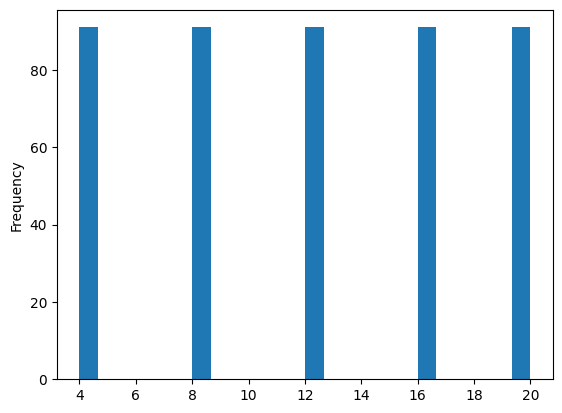

In [155]:
df_filtered["hour"] = df_filtered["datetime"].dt.hour
df_filtered["hour"].plot.hist(bins=24)


In [156]:
import numpy as np
import pandas as pd

def create_test_dataset(df, features, lookback=30):
    """
    Crea el dataset para LSTM usando NumPy strides (ultra rápido)
    y devuelve también los datetimes objetivo.
    
    Returns:
        X: np.ndarray de shape (num_samples, lookback, num_features)
        target_dt: pd.Series con los datetimes a predecir
    """
    # 1. Convertimos features a NumPy array
    feature_array = df[features].values
    
    # 2. Calculamos dimensiones
    num_samples = len(df) - lookback
    num_features = len(features)
    
    # 3. Crear ventanas con strides
    shape = (num_samples, lookback, num_features)
    strides = (feature_array.strides[0], feature_array.strides[0], feature_array.strides[1])
    
    X = np.lib.stride_tricks.as_strided(feature_array, shape=shape, strides=strides)
    
    # 4. Datetimes objetivo (los timestamps que vas a predecir)
    target_dt = df["datetime"].iloc[lookback:].reset_index(drop=True)
    
    return X, target_dt


In [157]:
test, test_dt = create_test_dataset(df_filtered, features, lookback=30)

In [158]:
test_dt

0     2026-01-28 04:00:00+00:00
1     2026-01-28 08:00:00+00:00
2     2026-01-28 12:00:00+00:00
3     2026-01-28 16:00:00+00:00
4     2026-01-28 20:00:00+00:00
                 ...           
420   2026-05-29 04:00:00+00:00
421   2026-05-29 08:00:00+00:00
422   2026-05-29 12:00:00+00:00
423   2026-05-29 16:00:00+00:00
424   2026-05-29 20:00:00+00:00
Name: datetime, Length: 425, dtype: datetime64[us, UTC]

In [159]:
test_g, test_dt_g = create_test_dataset(df_filtered, features_g, lookback=30)

In [160]:
test

array([[[ 2.64705882e-01, -1.40845070e+00,  0.00000000e+00, ...,
          6.03108328e-03,  6.90049226e-03,  3.88888889e+01],
        [ 4.76190476e-02, -3.38028169e+01,  0.00000000e+00, ...,
          2.09059233e-03,  9.05828811e-03,  1.83246073e+01],
        [ 6.36363636e-01, -2.81690141e+01,  0.00000000e+00, ...,
          2.31642344e-04,  9.41644562e-03,  1.78947368e+01],
        ...,
        [ 6.66666667e-01, -6.96969697e+01,  0.00000000e+00, ...,
         -6.83838614e-03,  4.18602367e-01, -3.89610390e+00],
        [ 2.30769231e-01, -4.24242424e+01,  1.00000000e+00, ...,
          4.13128299e-03, -9.85324155e-02,  1.15151515e+01],
        [ 5.83333333e-01, -4.84848485e+01,  1.00000000e+00, ...,
          5.98388953e-03, -8.92209391e-02,  1.21951220e+01]],

       [[ 4.76190476e-02, -3.38028169e+01,  0.00000000e+00, ...,
          2.09059233e-03,  9.05828811e-03,  1.83246073e+01],
        [ 6.36363636e-01, -2.81690141e+01,  0.00000000e+00, ...,
          2.31642344e-04,  9.41644562e

In [161]:
test_flat = test.reshape(-1, test.shape[-1])


In [162]:
test_flat

array([[ 2.64705882e-01, -1.40845070e+00,  0.00000000e+00, ...,
         6.03108328e-03,  6.90049226e-03,  3.88888889e+01],
       [ 4.76190476e-02, -3.38028169e+01,  0.00000000e+00, ...,
         2.09059233e-03,  9.05828811e-03,  1.83246073e+01],
       [ 6.36363636e-01, -2.81690141e+01,  0.00000000e+00, ...,
         2.31642344e-04,  9.41644562e-03,  1.78947368e+01],
       ...,
       [ 8.88888889e-01, -2.43902439e+00,  0.00000000e+00, ...,
         4.81574539e-03, -6.56086132e-02,  2.79411765e+01],
       [ 7.27272727e-01, -1.19047619e+01,  0.00000000e+00, ...,
         3.13938887e-03, -3.89673181e-02,  2.19858156e+01],
       [ 1.13207547e-01, -6.78571429e+01,  1.00000000e+00, ...,
        -5.03144654e-03,  1.27796013e-02,  2.38095238e+00]],
      shape=(12750, 73))

In [163]:
test_scaled =sc_features.transform(test_flat).reshape(test.shape)

In [164]:
import torch

def predict_in_batches(model, X_scaled, batch_size=512, device="cuda"):
    model.eval()
    preds = []

    with torch.no_grad():
        for i in range(0, len(X_scaled), batch_size):
            batch = X_scaled[i:i+batch_size]
            batch_t = torch.tensor(batch, dtype=torch.float32).to(device)
            logits = model(batch_t)
            preds.append(logits.cpu())

    return torch.cat(preds, dim=0)


In [165]:
logits_l1 = predict_in_batches(model_l1, test_scaled)
probs_l1 = torch.softmax(logits_l1, dim=1).numpy()


In [166]:
df_probs = pd.DataFrame(
    probs_l1,
    columns=["prob_hold", "prob_move"]
)

In [167]:
logits_l2 = predict_in_batches(model_l2, test_scaled)
probs_l2 = torch.softmax(logits_l2, dim=1).numpy()


In [168]:
df_probs_l2 = pd.DataFrame(
    probs_l2,
    columns=["prob_short", "prob_long"]
)

In [169]:
df_probs[["prob_short", "prob_long"]] = df_probs_l2


In [170]:
thresholds

{'threshold_move': 0.6, 'threshold_dir': 0.5}

In [171]:
logits_l3 = predict_in_batches(model_l3, test_scaled)
preds_l3 = logits_l3.numpy().reshape(-1)


In [172]:
df_probs["pred_l3"] = preds_l3

In [173]:
df_probs["pred_l1"] = (df_probs['prob_move'] > thresholds["threshold_move"]).astype(int)

In [174]:
df_probs["pred_l2"] =  (df_probs['prob_long'] > thresholds["threshold_dir"]).astype(int)

In [175]:
df_probs["datetime"] = test_dt.values

In [176]:
df_probs["pred"] = np.where(
    df_probs["pred_l1"] == 0,
    1,
    np.where(df_probs["pred_l2"] == 0, 0, 2)
)


In [177]:
df_final_triple_real = target_triple_barrier_interday(df_filtered, spec_bt, return_horizon_days=int(RETURN_HORIZON_MIN/60/24), profit_factor=1.8, tp_atr_mult=1.4, sl_atr_mult=1.2)
df_final_triple_real["target_class"] = df_final_triple_real[f"target_tb_{int(RETURN_HORIZON_MIN/60/24)}d"]
df_final_triple_real["target_regression"] = df_final_triple_real[f"log_return_horizon_{RETURN_HORIZON_MIN}m"]

In [178]:
df_final_triple_real

,datetime,open,high,low,close,volume,openint,per,trading_date,open_day,...,bars_between_swing_lows,swing_high_velocity,swing_low_velocity,bars_between_swings,swing_cycle_ratio,ticker,target_tb_2d,logreturn_tb_2d,target_class,target_regression
84,2026-01-20 04:00:00+00:00,1078.00,1084.50,1076.00,1084.25,472.0,0.0,240min,2026-01-20,1078.0,...,9.0,3.150000,1.111111,5.0,1.0,ZS,1.0,NaN,1.0,0.012296
85,2026-01-20 08:00:00+00:00,1083.50,1083.50,1078.25,1078.50,150.0,0.0,240min,2026-01-20,1078.0,...,9.0,3.150000,1.111111,5.0,1.2,ZS,1.0,NaN,1.0,0.009783
86,2026-01-20 12:00:00+00:00,1078.50,1079.75,1077.00,1079.50,226.0,0.0,240min,2026-01-20,1078.0,...,9.0,1.714286,1.111111,2.0,0.0,ZS,1.0,NaN,1.0,0.010008
87,2026-01-20 16:00:00+00:00,1079.50,1083.00,1077.75,1080.25,2395.0,0.0,240min,2026-01-20,1078.0,...,9.0,1.714286,1.111111,2.0,0.5,ZS,1.0,NaN,1.0,0.011405
88,2026-01-20 20:00:00+00:00,1080.25,1085.25,1075.25,1076.50,4709.0,0.0,240min,2026-01-20,1078.0,...,9.0,1.714286,1.111111,2.0,1.0,ZS,1.0,NaN,1.0,0.005589
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
532,2026-05-28 16:00:00+00:00,1194.25,1195.25,1187.25,1192.50,23000.0,0.0,240min,2026-05-28,1186.0,...,8.0,1.916667,1.437500,0.0,2.5,ZS,2.0,0.003614,2.0,0.002729
533,2026-05-28 20:00:00+00:00,1192.75,1196.00,1191.00,1195.75,24561.0,0.0,240min,2026-05-28,1186.0,...,8.0,4.062500,1.437500,4.0,0.0,ZS,2.0,0.003613,2.0,0.004610
534,2026-05-29 04:00:00+00:00,1198.00,1199.25,1194.75,1199.00,5519.0,0.0,240min,2026-05-29,1198.0,...,5.0,4.062500,1.750000,1.0,1.0,ZS,1.0,NaN,1.0,0.007114
535,2026-05-29 08:00:00+00:00,1199.25,1200.25,1195.75,1199.75,5111.0,0.0,240min,2026-05-29,1198.0,...,5.0,4.062500,1.750000,1.0,2.0,ZS,0.0,-0.008058,0.0,0.011949


In [179]:
df_final_triple_real["target_class"]

84     1.0
85     1.0
86     1.0
87     1.0
88     1.0
      ... 
532    2.0
533    2.0
534    1.0
535    0.0
536    0.0
Name: target_class, Length: 449, dtype: float64

In [180]:
df_probs

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred
0,0.031325,0.968675,0.611181,0.388819,-0.232277,1,0,2026-01-28 04:00:00,0
1,0.026675,0.973325,0.452542,0.547458,-0.176249,1,1,2026-01-28 08:00:00,2
2,0.028347,0.971652,0.326109,0.673891,-0.151196,1,1,2026-01-28 12:00:00,2
3,0.041066,0.958934,0.217776,0.782224,-0.097447,1,1,2026-01-28 16:00:00,2
4,0.135437,0.864563,0.442561,0.557439,-0.061266,1,1,2026-01-28 20:00:00,2
...,...,...,...,...,...,...,...,...,...
420,0.195544,0.804456,0.376974,0.623026,0.228421,1,1,2026-05-29 04:00:00,2
421,0.213700,0.786301,0.489960,0.510040,0.231982,1,1,2026-05-29 08:00:00,2
422,0.243119,0.756881,0.557374,0.442626,0.219804,1,0,2026-05-29 12:00:00,0
423,0.266609,0.733391,0.600844,0.399156,0.200549,1,0,2026-05-29 16:00:00,0


In [181]:
df_probs["datetime"] = pd.to_datetime(df_probs["datetime"], utc=True)


In [182]:
df_merged = df_probs.merge(df_final_triple_real[["datetime","target_class"]], left_on="datetime", right_on="datetime", how="left")

In [183]:
df_merged

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
0,0.031325,0.968675,0.611181,0.388819,-0.232277,1,0,2026-01-28 04:00:00+00:00,0,2.0
1,0.026675,0.973325,0.452542,0.547458,-0.176249,1,1,2026-01-28 08:00:00+00:00,2,2.0
2,0.028347,0.971652,0.326109,0.673891,-0.151196,1,1,2026-01-28 12:00:00+00:00,2,2.0
3,0.041066,0.958934,0.217776,0.782224,-0.097447,1,1,2026-01-28 16:00:00+00:00,2,2.0
4,0.135437,0.864563,0.442561,0.557439,-0.061266,1,1,2026-01-28 20:00:00+00:00,2,2.0
...,...,...,...,...,...,...,...,...,...,...
420,0.195544,0.804456,0.376974,0.623026,0.228421,1,1,2026-05-29 04:00:00+00:00,2,1.0
421,0.213700,0.786301,0.489960,0.510040,0.231982,1,1,2026-05-29 08:00:00+00:00,2,0.0
422,0.243119,0.756881,0.557374,0.442626,0.219804,1,0,2026-05-29 12:00:00+00:00,0,0.0
423,0.266609,0.733391,0.600844,0.399156,0.200549,1,0,2026-05-29 16:00:00+00:00,0,NaN


In [184]:
df_merged.loc[df_merged.pred != 1]

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
0,0.031325,0.968675,0.611181,0.388819,-0.232277,1,0,2026-01-28 04:00:00+00:00,0,2.0
1,0.026675,0.973325,0.452542,0.547458,-0.176249,1,1,2026-01-28 08:00:00+00:00,2,2.0
2,0.028347,0.971652,0.326109,0.673891,-0.151196,1,1,2026-01-28 12:00:00+00:00,2,2.0
3,0.041066,0.958934,0.217776,0.782224,-0.097447,1,1,2026-01-28 16:00:00+00:00,2,2.0
4,0.135437,0.864563,0.442561,0.557439,-0.061266,1,1,2026-01-28 20:00:00+00:00,2,2.0
...,...,...,...,...,...,...,...,...,...,...
419,0.167313,0.832687,0.263775,0.736225,0.180419,1,1,2026-05-28 20:00:00+00:00,2,2.0
420,0.195544,0.804456,0.376974,0.623026,0.228421,1,1,2026-05-29 04:00:00+00:00,2,1.0
421,0.213700,0.786301,0.489960,0.510040,0.231982,1,1,2026-05-29 08:00:00+00:00,2,0.0
422,0.243119,0.756881,0.557374,0.442626,0.219804,1,0,2026-05-29 12:00:00+00:00,0,0.0


In [185]:
df_merged.loc[df_merged.target_class != 1]

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
0,0.031325,0.968675,0.611181,0.388819,-0.232277,1,0,2026-01-28 04:00:00+00:00,0,2.0
1,0.026675,0.973325,0.452542,0.547458,-0.176249,1,1,2026-01-28 08:00:00+00:00,2,2.0
2,0.028347,0.971652,0.326109,0.673891,-0.151196,1,1,2026-01-28 12:00:00+00:00,2,2.0
3,0.041066,0.958934,0.217776,0.782224,-0.097447,1,1,2026-01-28 16:00:00+00:00,2,2.0
4,0.135437,0.864563,0.442561,0.557439,-0.061266,1,1,2026-01-28 20:00:00+00:00,2,2.0
...,...,...,...,...,...,...,...,...,...,...
419,0.167313,0.832687,0.263775,0.736225,0.180419,1,1,2026-05-28 20:00:00+00:00,2,2.0
421,0.213700,0.786301,0.489960,0.510040,0.231982,1,1,2026-05-29 08:00:00+00:00,2,0.0
422,0.243119,0.756881,0.557374,0.442626,0.219804,1,0,2026-05-29 12:00:00+00:00,0,0.0
423,0.266609,0.733391,0.600844,0.399156,0.200549,1,0,2026-05-29 16:00:00+00:00,0,NaN


In [186]:
test_flat_g = test_g.reshape(-1, test_g.shape[-1])


In [187]:
test_scaled_g =sc_features_g.transform(test_flat_g).reshape(test_g.shape)

In [188]:
logits_l1_g = predict_in_batches(model_l1_g, test_scaled_g)
probs_l1_g = torch.softmax(logits_l1_g, dim=1).numpy()


In [189]:
df_probs_g = pd.DataFrame(
    probs_l1_g,
    columns=["prob_hold", "prob_move"]
)

In [190]:
logits_l2_g = predict_in_batches(model_l2_g, test_scaled_g)
probs_l2_g = torch.softmax(logits_l2_g, dim=1).numpy()


In [191]:
df_probs_l2_g = pd.DataFrame(
    probs_l2_g,
    columns=["prob_short", "prob_long"]
)

In [192]:
df_probs_g[["prob_short", "prob_long"]] = df_probs_l2_g


In [193]:
logits_l3_g = predict_in_batches(model_l3_g, test_scaled_g)
preds_l3_g = logits_l3_g.numpy().reshape(-1)


In [194]:
df_probs_g["pred_l3"] = preds_l3_g

In [195]:
df_probs_g["pred_l1"] = (df_probs_g['prob_move'] > thresholds_g["threshold_move"]).astype(int)

In [196]:
df_probs_g["pred_l2"] =  (df_probs_g['prob_long'] > thresholds_g["threshold_dir"]).astype(int)

In [197]:
df_probs_g["datetime"] = test_dt_g.values


In [198]:
df_probs_g["pred"] = np.where(
    df_probs_g["pred_l1"] == 0,
    1,
    np.where(df_probs_g["pred_l2"] == 0, 0, 2)
)


In [199]:
df_probs_g

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred
0,0.214688,0.785312,0.171922,0.828078,-0.483359,1,1,2026-01-28 04:00:00,2
1,0.242818,0.757182,0.175227,0.824773,-0.580742,1,1,2026-01-28 08:00:00,2
2,0.214119,0.785881,0.173127,0.826873,-0.640737,1,1,2026-01-28 12:00:00,2
3,0.211636,0.788364,0.172510,0.827490,-0.630692,1,1,2026-01-28 16:00:00,2
4,0.313499,0.686501,0.184590,0.815410,-0.536880,1,1,2026-01-28 20:00:00,2
...,...,...,...,...,...,...,...,...,...
420,0.353809,0.646191,0.485435,0.514565,0.199512,1,1,2026-05-29 04:00:00,2
421,0.428150,0.571851,0.566481,0.433519,0.236720,0,0,2026-05-29 08:00:00,1
422,0.474287,0.525713,0.611740,0.388260,0.267215,0,0,2026-05-29 12:00:00,1
423,0.491364,0.508636,0.655331,0.344669,0.283354,0,0,2026-05-29 16:00:00,1


In [200]:
df_probs_g["datetime"] = pd.to_datetime(df_probs_g["datetime"], utc=True)


In [201]:
df_merged_g = df_probs_g.merge(df_final_triple_real[["datetime","target_class"]], left_on="datetime", right_on="datetime", how="left")

In [202]:
df_merged_g

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
0,0.214688,0.785312,0.171922,0.828078,-0.483359,1,1,2026-01-28 04:00:00+00:00,2,2.0
1,0.242818,0.757182,0.175227,0.824773,-0.580742,1,1,2026-01-28 08:00:00+00:00,2,2.0
2,0.214119,0.785881,0.173127,0.826873,-0.640737,1,1,2026-01-28 12:00:00+00:00,2,2.0
3,0.211636,0.788364,0.172510,0.827490,-0.630692,1,1,2026-01-28 16:00:00+00:00,2,2.0
4,0.313499,0.686501,0.184590,0.815410,-0.536880,1,1,2026-01-28 20:00:00+00:00,2,2.0
...,...,...,...,...,...,...,...,...,...,...
420,0.353809,0.646191,0.485435,0.514565,0.199512,1,1,2026-05-29 04:00:00+00:00,2,1.0
421,0.428150,0.571851,0.566481,0.433519,0.236720,0,0,2026-05-29 08:00:00+00:00,1,0.0
422,0.474287,0.525713,0.611740,0.388260,0.267215,0,0,2026-05-29 12:00:00+00:00,1,0.0
423,0.491364,0.508636,0.655331,0.344669,0.283354,0,0,2026-05-29 16:00:00+00:00,1,NaN


In [203]:
df_merged_g.loc[df_merged_g.pred != 1]

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
0,0.214688,0.785312,0.171922,0.828078,-0.483359,1,1,2026-01-28 04:00:00+00:00,2,2.0
1,0.242818,0.757182,0.175227,0.824773,-0.580742,1,1,2026-01-28 08:00:00+00:00,2,2.0
2,0.214119,0.785881,0.173127,0.826873,-0.640737,1,1,2026-01-28 12:00:00+00:00,2,2.0
3,0.211636,0.788364,0.172510,0.827490,-0.630692,1,1,2026-01-28 16:00:00+00:00,2,2.0
4,0.313499,0.686501,0.184590,0.815410,-0.536880,1,1,2026-01-28 20:00:00+00:00,2,2.0
...,...,...,...,...,...,...,...,...,...,...
416,0.085319,0.914681,0.316409,0.683591,-0.157141,1,1,2026-05-28 08:00:00+00:00,2,1.0
417,0.088615,0.911385,0.329182,0.670818,-0.010036,1,1,2026-05-28 12:00:00+00:00,2,1.0
418,0.114933,0.885067,0.354137,0.645863,0.040805,1,1,2026-05-28 16:00:00+00:00,2,2.0
419,0.229144,0.770856,0.405133,0.594867,0.122329,1,1,2026-05-28 20:00:00+00:00,2,2.0


In [204]:
df_merged_g.loc[df_merged_g.target_class != 1]

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
0,0.214688,0.785312,0.171922,0.828078,-0.483359,1,1,2026-01-28 04:00:00+00:00,2,2.0
1,0.242818,0.757182,0.175227,0.824773,-0.580742,1,1,2026-01-28 08:00:00+00:00,2,2.0
2,0.214119,0.785881,0.173127,0.826873,-0.640737,1,1,2026-01-28 12:00:00+00:00,2,2.0
3,0.211636,0.788364,0.172510,0.827490,-0.630692,1,1,2026-01-28 16:00:00+00:00,2,2.0
4,0.313499,0.686501,0.184590,0.815410,-0.536880,1,1,2026-01-28 20:00:00+00:00,2,2.0
...,...,...,...,...,...,...,...,...,...,...
419,0.229144,0.770856,0.405133,0.594867,0.122329,1,1,2026-05-28 20:00:00+00:00,2,2.0
421,0.428150,0.571851,0.566481,0.433519,0.236720,0,0,2026-05-29 08:00:00+00:00,1,0.0
422,0.474287,0.525713,0.611740,0.388260,0.267215,0,0,2026-05-29 12:00:00+00:00,1,0.0
423,0.491364,0.508636,0.655331,0.344669,0.283354,0,0,2026-05-29 16:00:00+00:00,1,NaN


In [205]:
df_probs

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred
0,0.031325,0.968675,0.611181,0.388819,-0.232277,1,0,2026-01-28 04:00:00+00:00,0
1,0.026675,0.973325,0.452542,0.547458,-0.176249,1,1,2026-01-28 08:00:00+00:00,2
2,0.028347,0.971652,0.326109,0.673891,-0.151196,1,1,2026-01-28 12:00:00+00:00,2
3,0.041066,0.958934,0.217776,0.782224,-0.097447,1,1,2026-01-28 16:00:00+00:00,2
4,0.135437,0.864563,0.442561,0.557439,-0.061266,1,1,2026-01-28 20:00:00+00:00,2
...,...,...,...,...,...,...,...,...,...
420,0.195544,0.804456,0.376974,0.623026,0.228421,1,1,2026-05-29 04:00:00+00:00,2
421,0.213700,0.786301,0.489960,0.510040,0.231982,1,1,2026-05-29 08:00:00+00:00,2
422,0.243119,0.756881,0.557374,0.442626,0.219804,1,0,2026-05-29 12:00:00+00:00,0
423,0.266609,0.733391,0.600844,0.399156,0.200549,1,0,2026-05-29 16:00:00+00:00,0


In [206]:
df_probs_g

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred
0,0.214688,0.785312,0.171922,0.828078,-0.483359,1,1,2026-01-28 04:00:00+00:00,2
1,0.242818,0.757182,0.175227,0.824773,-0.580742,1,1,2026-01-28 08:00:00+00:00,2
2,0.214119,0.785881,0.173127,0.826873,-0.640737,1,1,2026-01-28 12:00:00+00:00,2
3,0.211636,0.788364,0.172510,0.827490,-0.630692,1,1,2026-01-28 16:00:00+00:00,2
4,0.313499,0.686501,0.184590,0.815410,-0.536880,1,1,2026-01-28 20:00:00+00:00,2
...,...,...,...,...,...,...,...,...,...
420,0.353809,0.646191,0.485435,0.514565,0.199512,1,1,2026-05-29 04:00:00+00:00,2
421,0.428150,0.571851,0.566481,0.433519,0.236720,0,0,2026-05-29 08:00:00+00:00,1
422,0.474287,0.525713,0.611740,0.388260,0.267215,0,0,2026-05-29 12:00:00+00:00,1
423,0.491364,0.508636,0.655331,0.344669,0.283354,0,0,2026-05-29 16:00:00+00:00,1


In [207]:
df_merged_total = df_probs.merge(
    df_probs_g,
    on="datetime",
    how="left",
    suffixes=("_lstm", "_gru")
)


In [208]:
df_merged_total.head()

,prob_hold_lstm,prob_move_lstm,prob_short_lstm,prob_long_lstm,pred_l3_lstm,pred_l1_lstm,pred_l2_lstm,datetime,pred_lstm,prob_hold_gru,prob_move_gru,prob_short_gru,prob_long_gru,pred_l3_gru,pred_l1_gru,pred_l2_gru,pred_gru
0,0.031325,0.968675,0.611181,0.388819,-0.232277,1,0,2026-01-28 04:00:00+00:00,0,0.214688,0.785312,0.171922,0.828078,-0.483359,1,1,2
1,0.026675,0.973325,0.452542,0.547458,-0.176249,1,1,2026-01-28 08:00:00+00:00,2,0.242818,0.757182,0.175227,0.824773,-0.580742,1,1,2
2,0.028347,0.971652,0.326109,0.673891,-0.151196,1,1,2026-01-28 12:00:00+00:00,2,0.214119,0.785881,0.173127,0.826873,-0.640737,1,1,2
3,0.041066,0.958934,0.217776,0.782224,-0.097447,1,1,2026-01-28 16:00:00+00:00,2,0.211636,0.788364,0.172510,0.827490,-0.630692,1,1,2
4,0.135437,0.864563,0.442561,0.557439,-0.061266,1,1,2026-01-28 20:00:00+00:00,2,0.313499,0.686501,0.184590,0.815410,-0.536880,1,1,2


In [209]:
thresholds

{'threshold_move': 0.6, 'threshold_dir': 0.5}

In [210]:
thresholds_g

{'threshold_move': 0.6, 'threshold_dir': 0.5}

In [211]:
threshold_total = {
    k: min(thresholds[k], thresholds_g[k])
    for k in thresholds
}


In [212]:
threshold_total

{'threshold_move': 0.6, 'threshold_dir': 0.5}

In [213]:
eps = 1e-9
df_merged_total["peso_total"] = df_merged_total["pred_l3_lstm"] + df_merged_total["pred_l3_gru"] + eps

In [214]:
abs_l3_lstm = df_merged_total["pred_l3_lstm"].abs()
abs_l3_gru  = df_merged_total["pred_l3_gru"].abs()

In [215]:
weight_lstm = abs_l3_lstm / (abs_l3_lstm + abs_l3_gru + eps)
weight_gru  = abs_l3_gru  / (abs_l3_lstm + abs_l3_gru + eps)

In [216]:
df_merged_total["soft_move_score"] = (
    weight_lstm * df_merged_total["prob_move_lstm"] +
    weight_gru  * df_merged_total["prob_move_gru"]
)

In [217]:
df_merged_total

,prob_hold_lstm,prob_move_lstm,prob_short_lstm,prob_long_lstm,pred_l3_lstm,pred_l1_lstm,pred_l2_lstm,datetime,pred_lstm,prob_hold_gru,prob_move_gru,prob_short_gru,prob_long_gru,pred_l3_gru,pred_l1_gru,pred_l2_gru,pred_gru,peso_total,soft_move_score
0,0.031325,0.968675,0.611181,0.388819,-0.232277,1,0,2026-01-28 04:00:00+00:00,0,0.214688,0.785312,0.171922,0.828078,-0.483359,1,1,2,-0.715636,0.844827
1,0.026675,0.973325,0.452542,0.547458,-0.176249,1,1,2026-01-28 08:00:00+00:00,2,0.242818,0.757182,0.175227,0.824773,-0.580742,1,1,2,-0.756991,0.807506
2,0.028347,0.971652,0.326109,0.673891,-0.151196,1,1,2026-01-28 12:00:00+00:00,2,0.214119,0.785881,0.173127,0.826873,-0.640737,1,1,2,-0.791933,0.821348
3,0.041066,0.958934,0.217776,0.782224,-0.097447,1,1,2026-01-28 16:00:00+00:00,2,0.211636,0.788364,0.172510,0.827490,-0.630692,1,1,2,-0.728140,0.811192
4,0.135437,0.864563,0.442561,0.557439,-0.061266,1,1,2026-01-28 20:00:00+00:00,2,0.313499,0.686501,0.184590,0.815410,-0.536880,1,1,2,-0.598147,0.704739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420,0.195544,0.804456,0.376974,0.623026,0.228421,1,1,2026-05-29 04:00:00+00:00,2,0.353809,0.646191,0.485435,0.514565,0.199512,1,1,2,0.427933,0.730669
421,0.213700,0.786301,0.489960,0.510040,0.231982,1,1,2026-05-29 08:00:00+00:00,2,0.428150,0.571851,0.566481,0.433519,0.236720,0,0,1,0.468702,0.677992
422,0.243119,0.756881,0.557374,0.442626,0.219804,1,0,2026-05-29 12:00:00+00:00,0,0.474287,0.525713,0.611740,0.388260,0.267215,0,0,1,0.487019,0.630045
423,0.266609,0.733391,0.600844,0.399156,0.200549,1,0,2026-05-29 16:00:00+00:00,0,0.491364,0.508636,0.655331,0.344669,0.283354,0,0,1,0.483903,0.601784


In [218]:
df_merged_total["pred_soft_l1"] = (df_merged_total["soft_move_score"] > threshold_total["threshold_move"]).astype(int)


In [219]:
df_merged_total["sign_l3_lstm"] = np.sign(df_merged_total[df_merged_total.pred_l1_lstm == 1]["pred_l3_lstm"])
df_merged_total["sign_l3_gru"]  = np.sign(df_merged_total[df_merged_total.pred_l1_lstm == 1]["pred_l3_gru"])


In [220]:
cond_lstm = (
    (df_merged_total["pred_l2_lstm"] == 0) & (df_merged_total["sign_l3_lstm"] > 0) |   # SHORT pero retorno positivo
    (df_merged_total["pred_l2_lstm"] == 1) & (df_merged_total["sign_l3_lstm"] < 0)     # LONG pero retorno negativo
)

df_lstm_contra = df_merged_total[cond_lstm]


In [221]:
num_lstm_contra = cond_lstm.sum()


In [222]:
num_lstm_contra

np.int64(176)

In [223]:
cond_gru = (
    (df_merged_total["pred_l2_gru"] == 0) & (df_merged_total["sign_l3_gru"] > 0) |   # SHORT pero retorno positivo
    (df_merged_total["pred_l2_gru"] == 1) & (df_merged_total["sign_l3_gru"] < 0)     # LONG pero retorno negativo
)

df_gru_contra = df_merged_total[cond_gru]


In [224]:
num_gru_contra = cond_gru.sum()


In [225]:
num_gru_contra

np.int64(253)

In [226]:
df_moves = df_merged_total[df_merged_total.pred_soft_l1 == 1]

In [227]:
df_merged_total

,prob_hold_lstm,prob_move_lstm,prob_short_lstm,prob_long_lstm,pred_l3_lstm,pred_l1_lstm,pred_l2_lstm,datetime,pred_lstm,prob_hold_gru,...,prob_long_gru,pred_l3_gru,pred_l1_gru,pred_l2_gru,pred_gru,peso_total,soft_move_score,pred_soft_l1,sign_l3_lstm,sign_l3_gru
0,0.031325,0.968675,0.611181,0.388819,-0.232277,1,0,2026-01-28 04:00:00+00:00,0,0.214688,...,0.828078,-0.483359,1,1,2,-0.715636,0.844827,1,-1.0,-1.0
1,0.026675,0.973325,0.452542,0.547458,-0.176249,1,1,2026-01-28 08:00:00+00:00,2,0.242818,...,0.824773,-0.580742,1,1,2,-0.756991,0.807506,1,-1.0,-1.0
2,0.028347,0.971652,0.326109,0.673891,-0.151196,1,1,2026-01-28 12:00:00+00:00,2,0.214119,...,0.826873,-0.640737,1,1,2,-0.791933,0.821348,1,-1.0,-1.0
3,0.041066,0.958934,0.217776,0.782224,-0.097447,1,1,2026-01-28 16:00:00+00:00,2,0.211636,...,0.827490,-0.630692,1,1,2,-0.728140,0.811192,1,-1.0,-1.0
4,0.135437,0.864563,0.442561,0.557439,-0.061266,1,1,2026-01-28 20:00:00+00:00,2,0.313499,...,0.815410,-0.536880,1,1,2,-0.598147,0.704739,1,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420,0.195544,0.804456,0.376974,0.623026,0.228421,1,1,2026-05-29 04:00:00+00:00,2,0.353809,...,0.514565,0.199512,1,1,2,0.427933,0.730669,1,1.0,1.0
421,0.213700,0.786301,0.489960,0.510040,0.231982,1,1,2026-05-29 08:00:00+00:00,2,0.428150,...,0.433519,0.236720,0,0,1,0.468702,0.677992,1,1.0,1.0
422,0.243119,0.756881,0.557374,0.442626,0.219804,1,0,2026-05-29 12:00:00+00:00,0,0.474287,...,0.388260,0.267215,0,0,1,0.487019,0.630045,1,1.0,1.0
423,0.266609,0.733391,0.600844,0.399156,0.200549,1,0,2026-05-29 16:00:00+00:00,0,0.491364,...,0.344669,0.283354,0,0,1,0.483903,0.601784,1,1.0,1.0


In [228]:
df_moves["sign_l3_lstm"] = np.sign(df_moves["pred_l3_lstm"])
df_moves["sign_l3_gru"]  = np.sign(df_moves["pred_l3_gru"])
cond_disagree = df_moves["sign_l3_lstm"] != df_moves["sign_l3_gru"]
df_l3_disagree = df_moves[cond_disagree]
num_disagree = cond_disagree.sum()
total_moves = len(df_moves)
ratio_disagree = num_disagree / total_moves

cond_l2_disagree = df_moves["pred_l2_lstm"] != df_moves["pred_l2_gru"]
df_l2_disagree = df_moves[cond_l2_disagree]

num_l2_disagree = cond_l2_disagree.sum()
ratio_l2_disagree = num_l2_disagree / total_moves


In [229]:
ratio_disagree

np.float64(0.27419354838709675)

In [230]:
ratio_l2_disagree

np.float64(0.5053763440860215)

In [231]:
summary = pd.DataFrame({
    "metric": ["L3_sign_disagree", "L2_direction_disagree"],
    "count": [num_disagree, num_l2_disagree],
    "total_moves_softvote": [total_moves, total_moves],
    "ratio": [ratio_disagree, ratio_l2_disagree]
})


In [232]:
summary

,metric,count,total_moves_softvote,ratio
0,L3_sign_disagree,51,186,0.274194
1,L2_direction_disagree,94,186,0.505376


In [233]:
eps = 1e-9
abs_l3_lstm = df_merged_total["pred_l3_lstm"].abs()
abs_l3_gru  = df_merged_total["pred_l3_gru"].abs()

w_lstm = abs_l3_lstm / (abs_l3_lstm + abs_l3_gru + eps)
w_gru  = abs_l3_gru  / (abs_l3_lstm + abs_l3_gru + eps)


In [234]:
df_merged_total["soft_long_score"] = (
    w_lstm * df_merged_total["prob_long_lstm"] +
    w_gru  * df_merged_total["prob_long_gru"]
)


In [235]:
df_merged_total["soft_short_score"] = (
    w_lstm * df_merged_total["prob_short_lstm"] +
    w_gru  * df_merged_total["prob_short_gru"]
)


In [236]:
df_merged_total["pred_soft_l2"] = (
    df_merged_total["soft_long_score"] > threshold_total["threshold_dir"]
).astype(int)


In [237]:
df_merged_total["l3_total"] = (
    w_lstm * df_merged_total["pred_l3_lstm"] +
    w_gru  * df_merged_total["pred_l3_gru"]
)

df_merged_total["sign_l3_total"] = np.sign(df_merged_total["l3_total"])


In [238]:
df_merged_total["pred_soft_l2_clean"] = np.where(
    df_merged_total["sign_l3_total"] == 0,  # retorno débil
    np.nan,                                 # descartar
    df_merged_total["pred_soft_l2"]         # mantener
)


In [239]:
df_merged_total["pred_soft_final"] = np.where(
    df_merged_total["pred_soft_l1"] == 0, 
    1,  # HOLD
    np.where(
        df_merged_total["pred_soft_l2_clean"].isna(),
        1,  # HOLD si la dirección no es coherente
        np.where(df_merged_total["pred_soft_l2_clean"] == 0, 0, 2)  # SHORT o LONG
    )
)


In [240]:
df_merged_final = df_merged_total.merge(df_final_triple_real[["datetime","target_class","target_regression"]], left_on="datetime", right_on="datetime", how="left")

In [241]:
df_merged_final.head()

,prob_hold_lstm,prob_move_lstm,prob_short_lstm,prob_long_lstm,pred_l3_lstm,pred_l1_lstm,pred_l2_lstm,datetime,pred_lstm,prob_hold_gru,...,sign_l3_gru,soft_long_score,soft_short_score,pred_soft_l2,l3_total,sign_l3_total,pred_soft_l2_clean,pred_soft_final,target_class,target_regression
0,0.031325,0.968675,0.611181,0.388819,-0.232277,1,0,2026-01-28 04:00:00+00:00,0,0.214688,...,-1.0,0.685506,0.314494,1,-0.401864,-1.0,1.0,2,2.0,0.002508
1,0.026675,0.973325,0.452542,0.547458,-0.176249,1,1,2026-01-28 08:00:00+00:00,2,0.242818,...,-1.0,0.760206,0.239794,1,-0.486565,-1.0,1.0,2,2.0,0.005479
2,0.028347,0.971652,0.326109,0.673891,-0.151196,1,1,2026-01-28 12:00:00+00:00,2,0.214119,...,-1.0,0.797666,0.202334,1,-0.547273,-1.0,1.0,2,2.0,0.003182
3,0.041066,0.958934,0.217776,0.782224,-0.097447,1,1,2026-01-28 16:00:00+00:00,2,0.211636,...,-1.0,0.821432,0.178568,1,-0.559328,-1.0,1.0,2,2.0,0.001136
4,0.135437,0.864563,0.442561,0.557439,-0.061266,1,1,2026-01-28 20:00:00+00:00,2,0.313499,...,-1.0,0.788987,0.211013,1,-0.488165,-1.0,1.0,2,2.0,0.003868


In [242]:
conf_mat = pd.crosstab(
    df_merged_final["pred_soft_final"],
    df_merged_final["target_class"],
    rownames=["pred_soft_final"],
    colnames=["target_class"]
)
conf_mat


target_class,0.0,1.0,2.0
pred_soft_final,,,
0,15,54,19
1,34,164,37
2,15,58,23


In [243]:
accuracy_short = conf_mat.loc[0, 0] / conf_mat.loc[0].sum() if 0 in conf_mat.index else None
accuracy_hold  = conf_mat.loc[1, 1] / conf_mat.loc[1].sum() if 1 in conf_mat.index else None
accuracy_long  = conf_mat.loc[2, 2] / conf_mat.loc[2].sum() if 2 in conf_mat.index else None

accuracy_short, accuracy_hold, accuracy_long


(np.float64(0.17045454545454544),
 np.float64(0.6978723404255319),
 np.float64(0.23958333333333334))

In [244]:
accuracy_total = (df_merged_final["pred_soft_final"] == df_merged_final["target_class"]).mean()
accuracy_total


np.float64(0.4752941176470588)

In [245]:
df_ops = df_merged_final[df_merged_final["pred_soft_final"] != 1]

accuracy_ops = (df_ops["pred_soft_final"] == df_ops["target_class"]).mean()
accuracy_ops


np.float64(0.20430107526881722)

In [246]:
df_merged_final.groupby("pred_soft_final")["target_regression"].mean()


pred_soft_final
0   -0.001130
1    0.003446
2    0.003214
Name: target_regression, dtype: float64

In [247]:
# Filtrar solo operaciones (SHORT o LONG)
df_ops = df_merged_final[df_merged_final["pred_soft_final"] != 1]

# Retornos reales de esas operaciones
returns = df_ops["target_regression"]

# Sharpe ratio (sin tasa libre de riesgo)
sharpe = returns.mean() / returns.std()

sharpe


np.float64(0.0746040915244049)

In [248]:
df_long = df_merged_final[df_merged_final["pred_soft_final"] == 2]
sharpe_long = df_long["target_regression"].mean() / df_long["target_regression"].std()
sharpe_long


np.float64(0.2417719898847233)

In [249]:
threshold = df_merged_final["l3_total"].abs().quantile(0.7)


In [250]:
df_long_strong = df_merged_final[
    (df_merged_final["pred_soft_final"] == 2) &
    (df_merged_final["l3_total"].abs() > threshold)
]


In [251]:
returns = df_long_strong["target_regression"]

sharpe_long_filtered = returns.mean() / returns.std()
sharpe_long_filtered


np.float64(0.059277518325262346)

In [252]:
df_long_strong

,prob_hold_lstm,prob_move_lstm,prob_short_lstm,prob_long_lstm,pred_l3_lstm,pred_l1_lstm,pred_l2_lstm,datetime,pred_lstm,prob_hold_gru,...,sign_l3_gru,soft_long_score,soft_short_score,pred_soft_l2,l3_total,sign_l3_total,pred_soft_l2_clean,pred_soft_final,target_class,target_regression
0,0.031325,0.968675,0.611181,0.388819,-0.232277,1,0,2026-01-28 04:00:00+00:00,0,0.214688,...,-1.0,0.685506,0.314494,1,-0.401864,-1.0,1.0,2,2.0,0.002508
1,0.026675,0.973325,0.452542,0.547458,-0.176249,1,1,2026-01-28 08:00:00+00:00,2,0.242818,...,-1.0,0.760206,0.239794,1,-0.486565,-1.0,1.0,2,2.0,0.005479
2,0.028347,0.971652,0.326109,0.673891,-0.151196,1,1,2026-01-28 12:00:00+00:00,2,0.214119,...,-1.0,0.797666,0.202334,1,-0.547273,-1.0,1.0,2,2.0,0.003182
3,0.041066,0.958934,0.217776,0.782224,-0.097447,1,1,2026-01-28 16:00:00+00:00,2,0.211636,...,-1.0,0.821432,0.178568,1,-0.559328,-1.0,1.0,2,2.0,0.001136
4,0.135437,0.864563,0.442561,0.557439,-0.061266,1,1,2026-01-28 20:00:00+00:00,2,0.313499,...,-1.0,0.788987,0.211013,1,-0.488165,-1.0,1.0,2,2.0,0.003868
5,0.270274,0.729726,0.594491,0.405509,0.037821,1,0,2026-01-29 04:00:00+00:00,0,0.330673,...,-1.0,0.789975,0.210025,1,-0.379067,-1.0,1.0,2,1.0,0.013451
11,0.108481,0.891519,0.778165,0.221835,-0.024523,1,0,2026-01-30 08:00:00+00:00,0,0.365903,...,-1.0,0.717969,0.282031,1,-0.321207,-1.0,1.0,2,1.0,0.000915
21,0.105187,0.894813,0.532890,0.467110,-0.269831,1,0,2026-02-03 08:00:00+00:00,0,0.202808,...,-1.0,0.694998,0.305002,1,-0.366507,-1.0,1.0,2,1.0,-0.011431
22,0.076747,0.923253,0.475369,0.524631,-0.294163,1,1,2026-02-03 12:00:00+00:00,2,0.120687,...,-1.0,0.732732,0.267268,1,-0.438277,-1.0,1.0,2,1.0,-0.001829
23,0.068181,0.931819,0.361123,0.638877,-0.251966,1,1,2026-02-03 16:00:00+00:00,2,0.102100,...,-1.0,0.792221,0.207779,1,-0.422805,-1.0,1.0,2,1.0,-0.000686


In [253]:
df_for_bt = df_filtered[["open","close","high","low","atr","datetime"]].merge(df_long_strong, how="outer", on="datetime")

In [254]:
def run_backtest(df, tp_mult=1.5, sl_mult=1.0):
    """
    df debe contener:
        - datetime
        - open, high, low, close
        - atr
        - pred_soft_final (0 short, 1 hold, 2 long)
    """

    df = df.sort_values("datetime").reset_index(drop=True)

    equity = 0.0
    position = None
    entry_price = None
    sl = None
    tp = None

    trades = []  # lista de dicts con info de cada trade
    equity_curve = []

    for i, row in df.iterrows():

        # ============================================================
        # 1. Si hay posición abierta → comprobar SL/TP
        # ============================================================
        if position is not None:

            if position == "long":
                # SL-first
                if row["low"] <= sl:
                    pnl = sl - entry_price
                    trades.append({"type": "long", "entry": entry_price, "exit": sl, "pnl": pnl, "datetime_exit": row["datetime"]})
                    equity += pnl
                    position = None

                # TP-second
                elif row["high"] >= tp:
                    pnl = tp - entry_price
                    trades.append({"type": "long", "entry": entry_price, "exit": tp, "pnl": pnl, "datetime_exit": row["datetime"]})
                    equity += pnl
                    position = None

            elif position == "short":
                # SL-first
                if row["high"] >= sl:
                    pnl = entry_price - sl
                    trades.append({"type": "short", "entry": entry_price, "exit": sl, "pnl": pnl, "datetime_exit": row["datetime"]})
                    equity += pnl
                    position = None

                # TP-second
                elif row["low"] <= tp:
                    pnl = entry_price - tp
                    trades.append({"type": "short", "entry": entry_price, "exit": tp, "pnl": pnl, "datetime_exit": row["datetime"]})
                    equity += pnl
                    position = None

        # ============================================================
        # 2. Si NO hay posición abierta → comprobar señal nueva
        # ============================================================
        if position is None:

            signal = row["pred_soft_final"]

            if signal == 2:  # LONG
                position = "long"
                entry_price = row["open"]
                sl = entry_price - sl_mult * row["atr"]
                tp = entry_price + tp_mult * row["atr"]
                entry_dt = row["datetime"]

            elif signal == 0:  # SHORT
                position = "short"
                entry_price = row["open"]
                sl = entry_price + sl_mult * row["atr"]
                tp = entry_price - tp_mult * row["atr"]
                entry_dt = row["datetime"]

        # ============================================================
        # 3. Guardar equity en cada vela
        # ============================================================
        equity_curve.append(equity)

    return trades, equity_curve


In [255]:
trades, equity = run_backtest(df_for_bt)

In [256]:
trades

[{'type': 'long',
  'entry': 1092.25,
  'exit': 1099.4255350518972,
  'pnl': 7.175535051897214,
  'datetime_exit': Timestamp('2026-01-28 08:00:00+0000', tz='UTC')},
 {'type': 'long',
  'entry': 1098.25,
  'exit': 1104.8187970449776,
  'pnl': 6.5687970449776,
  'datetime_exit': Timestamp('2026-01-28 16:00:00+0000', tz='UTC')},
 {'type': 'long',
  'entry': 1101.75,
  'exit': 1109.3505631137832,
  'pnl': 7.60056311378321,
  'datetime_exit': Timestamp('2026-01-29 16:00:00+0000', tz='UTC')},
 {'type': 'long',
  'entry': 1094.25,
  'exit': 1088.342559123207,
  'pnl': -5.907440876793089,
  'datetime_exit': Timestamp('2026-01-30 20:00:00+0000', tz='UTC')},
 {'type': 'long',
  'entry': 1088.0,
  'exit': 1095.4036566986229,
  'pnl': 7.403656698622854,
  'datetime_exit': Timestamp('2026-02-03 16:00:00+0000', tz='UTC')},
 {'type': 'long',
  'entry': 1092.5,
  'exit': 1087.3993541272082,
  'pnl': -5.100645872791802,
  'datetime_exit': Timestamp('2026-02-04 12:00:00+0000', tz='UTC')},
 {'type': 'lon

In [257]:
equity

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 7.175535051897214,
 7.175535051897214,
 13.744332096874814,
 13.744332096874814,
 13.744332096874814,
 13.744332096874814,
 13.744332096874814,
 21.344895210658024,
 21.344895210658024,
 21.344895210658024,
 21.344895210658024,
 21.344895210658024,
 21.344895210658024,
 15.437454333864935,
 15.437454333864935,
 15.437454333864935,
 15.437454333864935,
 15.437454333864935,
 15.437454333864935,
 15.437454333864935,
 15.437454333864935,
 15.437454333864935,
 22.841111032487788,
 22.841111032487788,
 22.841111032487788,
 22.841111032487788,
 17.740465159695987,
 17.740465159695987,
 17.740465159695987,
 17.740465159695987,
 17.740465159695987,
 17.740465159695987,
 33.092057970178985,
 33.092057970178985,
 33.092057970178985,
 33.092057970178985,
 33.092057970178985,
 33.092057970178985,
 33.09205797017898

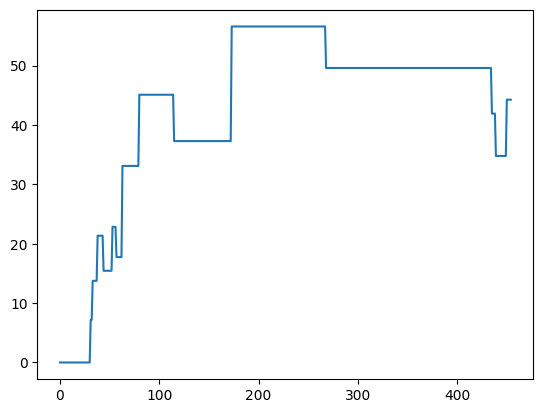

In [258]:
import matplotlib.pyplot as plt
plt.plot(equity)

In [259]:
def run_backtest_scale_in(df, tp_mult=1.5, sl_mult=1.0):
    """
    df debe contener:
        - datetime
        - open, high, low, close
        - atr
        - pred_soft_final (0 short, 1 hold, 2 long)
    """

    df = df.sort_values("datetime").reset_index(drop=True)

    open_positions = []   # lista de dicts con posiciones abiertas
    closed_trades = []    # lista de dicts con trades cerrados
    equity_curve = []
    equity = 0.0

    for i, row in df.iterrows():

        # ============================================================
        # 1. Actualizar TODAS las posiciones abiertas (scale-in)
        # ============================================================
        still_open = []

        for pos in open_positions:

            if pos["type"] == "long":

                # SL-first
                if row["low"] <= pos["sl"]:
                    pnl = pos["sl"] - pos["entry"]
                    closed_trades.append({
                        "type": "long",
                        "entry": pos["entry"],
                        "exit": pos["sl"],
                        "pnl": pnl,
                        "datetime_exit": row["datetime"]
                    })
                    equity += pnl
                    continue

                # TP-second
                elif row["high"] >= pos["tp"]:
                    pnl = pos["tp"] - pos["entry"]
                    closed_trades.append({
                        "type": "long",
                        "entry": pos["entry"],
                        "exit": pos["tp"],
                        "pnl": pnl,
                        "datetime_exit": row["datetime"]
                    })
                    equity += pnl
                    continue

                # Si no se ha cerrado, sigue abierta
                still_open.append(pos)

            elif pos["type"] == "short":

                # SL-first
                if row["high"] >= pos["sl"]:
                    pnl = pos["entry"] - pos["sl"]
                    closed_trades.append({
                        "type": "short",
                        "entry": pos["entry"],
                        "exit": pos["sl"],
                        "pnl": pnl,
                        "datetime_exit": row["datetime"]
                    })
                    equity += pnl
                    continue

                # TP-second
                elif row["low"] <= pos["tp"]:
                    pnl = pos["entry"] - pos["tp"]
                    closed_trades.append({
                        "type": "short",
                        "entry": pos["entry"],
                        "exit": pos["tp"],
                        "pnl": pnl,
                        "datetime_exit": row["datetime"]
                    })
                    equity += pnl
                    continue

                still_open.append(pos)

        open_positions = still_open

        # ============================================================
        # 2. Abrir NUEVAS posiciones (scale-in)
        # ============================================================
        signal = row["pred_soft_final"]

        if signal == 2:  # LONG
            entry = row["open"]
            sl = entry - sl_mult * row["atr"]
            tp = entry + tp_mult * row["atr"]

            open_positions.append({
                "type": "long",
                "entry": entry,
                "sl": sl,
                "tp": tp,
                "datetime_entry": row["datetime"]
            })

        elif signal == 0:  # SHORT
            entry = row["open"]
            sl = entry + sl_mult * row["atr"]
            tp = entry - tp_mult * row["atr"]

            open_positions.append({
                "type": "short",
                "entry": entry,
                "sl": sl,
                "tp": tp,
                "datetime_entry": row["datetime"]
            })

        # ============================================================
        # 3. Guardar equity
        # ============================================================
        equity_curve.append(equity)

    return closed_trades, equity_curve


In [260]:
trades_s, equity_s = run_backtest_scale_in(df_for_bt)

In [261]:
trades_s

[{'type': 'long',
  'entry': 1092.25,
  'exit': 1099.4255350518972,
  'pnl': 7.175535051897214,
  'datetime_exit': Timestamp('2026-01-28 08:00:00+0000', tz='UTC')},
 {'type': 'long',
  'entry': 1098.25,
  'exit': 1104.8187970449776,
  'pnl': 6.5687970449776,
  'datetime_exit': Timestamp('2026-01-28 16:00:00+0000', tz='UTC')},
 {'type': 'long',
  'entry': 1098.75,
  'exit': 1105.4429574389806,
  'pnl': 6.692957438980557,
  'datetime_exit': Timestamp('2026-01-28 16:00:00+0000', tz='UTC')},
 {'type': 'long',
  'entry': 1101.75,
  'exit': 1109.3505631137832,
  'pnl': 7.60056311378321,
  'datetime_exit': Timestamp('2026-01-29 16:00:00+0000', tz='UTC')},
 {'type': 'long',
  'entry': 1100.75,
  'exit': 1108.587154698612,
  'pnl': 7.837154698612039,
  'datetime_exit': Timestamp('2026-01-29 16:00:00+0000', tz='UTC')},
 {'type': 'long',
  'entry': 1101.0,
  'exit': 1108.5922007387971,
  'pnl': 7.592200738797146,
  'datetime_exit': Timestamp('2026-01-29 16:00:00+0000', tz='UTC')},
 {'type': 'long

In [262]:
equity_s

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 7.175535051897214,
 7.175535051897214,
 20.43728953585537,
 20.43728953585537,
 20.43728953585537,
 20.43728953585537,
 20.43728953585537,
 43.467208087047766,
 43.467208087047766,
 43.467208087047766,
 43.467208087047766,
 43.467208087047766,
 43.467208087047766,
 37.55976721025468,
 37.55976721025468,
 37.55976721025468,
 37.55976721025468,
 37.55976721025468,
 37.55976721025468,
 37.55976721025468,
 37.55976721025468,
 37.55976721025468,
 52.57992638101723,
 52.57992638101723,
 52.57992638101723,
 52.57992638101723,
 47.47928050822543,
 47.47928050822543,
 47.47928050822543,
 47.47928050822543,
 47.47928050822543,
 47.47928050822543,
 62.83087331870843,
 62.83087331870843,
 62.83087331870843,
 62.83087331870843,
 62.83087331870843,
 62.83087331870843,
 62.83087331870843,
 62.83087331870843,
 62.8308

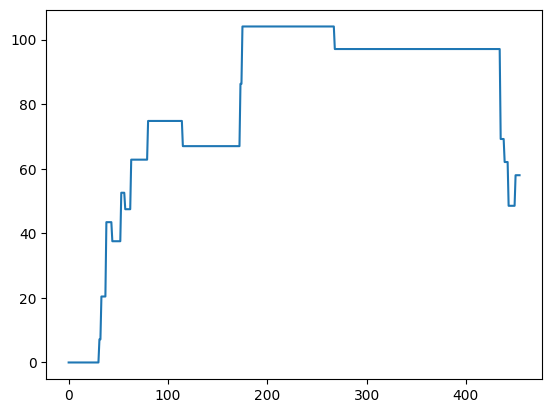

In [263]:
plt.plot(equity_s)

In [264]:
def run_backtest_dynamic(df, tp_mult=1.5, sl_mult=1.0, risk_per_trade=1.0):
    """
    Backtest sin scale-in pero con dynamic sizing basado en ATR.
    df debe contener:
        - datetime
        - open, high, low, close
        - atr
        - pred_soft_final (0 short, 1 hold, 2 long)
    """

    df = df.sort_values("datetime").reset_index(drop=True)

    equity = 0.0
    position = None
    entry_price = None
    sl = None
    tp = None
    size = None

    trades = []
    equity_curve = []

    for i, row in df.iterrows():

        # ============================================================
        # 1. Si hay posición abierta → comprobar SL/TP
        # ============================================================
        if position is not None:

            if position == "long":

                # SL-first
                if row["low"] <= sl:
                    pnl = (sl - entry_price) * size
                    trades.append({
                        "type": "long",
                        "entry": entry_price,
                        "exit": sl,
                        "pnl": pnl,
                        "size": size,
                        "datetime_exit": row["datetime"]
                    })
                    equity += pnl
                    position = None

                # TP-second
                elif row["high"] >= tp:
                    pnl = (tp - entry_price) * size
                    trades.append({
                        "type": "long",
                        "entry": entry_price,
                        "exit": tp,
                        "pnl": pnl,
                        "size": size,
                        "datetime_exit": row["datetime"]
                    })
                    equity += pnl
                    position = None

            elif position == "short":

                # SL-first
                if row["high"] >= sl:
                    pnl = (entry_price - sl) * size
                    trades.append({
                        "type": "short",
                        "entry": entry_price,
                        "exit": sl,
                        "pnl": pnl,
                        "size": size,
                        "datetime_exit": row["datetime"]
                    })
                    equity += pnl
                    position = None

                # TP-second
                elif row["low"] <= tp:
                    pnl = (entry_price - tp) * size
                    trades.append({
                        "type": "short",
                        "entry": entry_price,
                        "exit": tp,
                        "pnl": pnl,
                        "size": size,
                        "datetime_exit": row["datetime"]
                    })
                    equity += pnl
                    position = None

        # ============================================================
        # 2. Si NO hay posición abierta → comprobar señal nueva
        # ============================================================
        if position is None:

            signal = row["pred_soft_final"]

            if signal == 2:  # LONG
                position = "long"
                entry_price = row["open"]
                sl = entry_price - sl_mult * row["atr"]
                tp = entry_price + tp_mult * row["atr"]
                size = risk_per_trade / row["atr"]

            elif signal == 0:  # SHORT
                position = "short"
                entry_price = row["open"]
                sl = entry_price + sl_mult * row["atr"]
                tp = entry_price - tp_mult * row["atr"]
                size = risk_per_trade / row["atr"]

        # ============================================================
        # 3. Guardar equity
        # ============================================================
        equity_curve.append(equity)

    return trades, equity_curve


In [265]:
trades_d, equity_d = run_backtest_dynamic(df_for_bt)

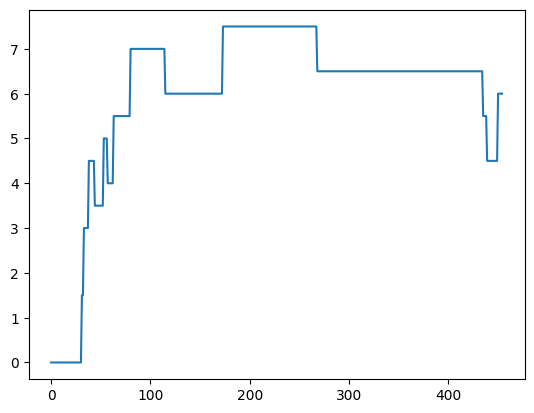

In [266]:
plt.plot(equity_d)

In [267]:
def run_backtest_scale_in_dynamic(df, tp_mult=1.5, sl_mult=1.0, risk_per_trade=1.0):
    """
    Backtest con scale-in y dynamic sizing basado en ATR.
    df debe contener:
        - datetime
        - open, high, low, close
        - atr
        - pred_soft_final (0 short, 1 hold, 2 long)
    """

    df = df.sort_values("datetime").reset_index(drop=True)

    open_positions = []
    closed_trades = []
    equity_curve = []
    equity = 0.0

    for i, row in df.iterrows():

        # ============================================================
        # 1. Actualizar TODAS las posiciones abiertas
        # ============================================================
        still_open = []

        for pos in open_positions:

            if pos["type"] == "long":

                # SL-first
                if row["low"] <= pos["sl"]:
                    pnl = (pos["sl"] - pos["entry"]) * pos["size"]
                    closed_trades.append({
                        "type": "long",
                        "entry": pos["entry"],
                        "exit": pos["sl"],
                        "pnl": pnl,
                        "size": pos["size"],
                        "datetime_exit": row["datetime"]
                    })
                    equity += pnl
                    continue

                # TP-second
                elif row["high"] >= pos["tp"]:
                    pnl = (pos["tp"] - pos["entry"]) * pos["size"]
                    closed_trades.append({
                        "type": "long",
                        "entry": pos["entry"],
                        "exit": pos["tp"],
                        "pnl": pnl,
                        "size": pos["size"],
                        "datetime_exit": row["datetime"]
                    })
                    equity += pnl
                    continue

                still_open.append(pos)

            elif pos["type"] == "short":

                # SL-first
                if row["high"] >= pos["sl"]:
                    pnl = (pos["entry"] - pos["sl"]) * pos["size"]
                    closed_trades.append({
                        "type": "short",
                        "entry": pos["entry"],
                        "exit": pos["sl"],
                        "pnl": pnl,
                        "size": pos["size"],
                        "datetime_exit": row["datetime"]
                    })
                    equity += pnl
                    continue

                # TP-second
                elif row["low"] <= pos["tp"]:
                    pnl = (pos["entry"] - pos["tp"]) * pos["size"]
                    closed_trades.append({
                        "type": "short",
                        "entry": pos["entry"],
                        "exit": pos["tp"],
                        "pnl": pnl,
                        "size": pos["size"],
                        "datetime_exit": row["datetime"]
                    })
                    equity += pnl
                    continue

                still_open.append(pos)

        open_positions = still_open

        # ============================================================
        # 2. Abrir nuevas posiciones (scale-in)
        # ============================================================
        signal = row["pred_soft_final"]

        if signal == 2:  # LONG
            entry = row["open"]
            sl = entry - sl_mult * row["atr"]
            tp = entry + tp_mult * row["atr"]
            size = risk_per_trade / row["atr"]

            open_positions.append({
                "type": "long",
                "entry": entry,
                "sl": sl,
                "tp": tp,
                "size": size,
                "datetime_entry": row["datetime"]
            })

        elif signal == 0:  # SHORT
            entry = row["open"]
            sl = entry + sl_mult * row["atr"]
            tp = entry - tp_mult * row["atr"]
            size = risk_per_trade / row["atr"]

            open_positions.append({
                "type": "short",
                "entry": entry,
                "sl": sl,
                "tp": tp,
                "size": size,
                "datetime_entry": row["datetime"]
            })

        # ============================================================
        # 3. Guardar equity
        # ============================================================
        equity_curve.append(equity)

    return closed_trades, equity_curve


In [268]:
trades_ds, equity_ds = run_backtest_scale_in_dynamic(df_for_bt)

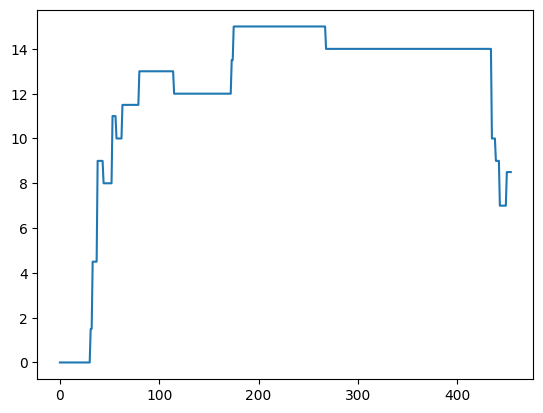

In [269]:
plt.plot(equity_ds)

In [270]:
specs = load_specs()

In [271]:
specs[ASSET]

{'name': 'Soybean Futures',
 'symbol': 'ZS',
 'ib_symbol': 'ZS',
 'exchange': 'CBOT',
 'currency': 'USD',
 'approx_total_fee_per_side': 2.5,
 'min_slippage_ticks': 1,
 'max_spread_ticks': 5,
 'fallback_margin': 5000,
 'conId': 597391723,
 'multiplier': 5000.0,
 'tick_size': 0.0025,
 'tick_value': 12.5,
 'trading_hours': '20260620:CLOSED;20260621:1900-20260622:0745;20260622:0830-20260622:1320;20260622:1900-20260623:0745;20260623:0830-20260623:1320;20260623:1900-20260624:0745;20260624:0830-20260624:1320;20260624:1900-20260625:0745;20260625:0830-20260625:1320;20260625:1900-20260626:0745;20260626:0830-20260626:1320',
 'liquid_hours': '20260620:CLOSED;20260621:CLOSED;20260622:0830-20260622:1320;20260623:0830-20260623:1320;20260624:0830-20260624:1320;20260625:0830-20260625:1320;20260625:1900-20260626:0745;20260626:0830-20260626:1320',
 'min_profit_ticks': 2.4,
 'initial_margin': 5000,
 'maint_margin': 4500.0,
 'fetched_at': '2026-06-20T14:42:12.156445+00:00'}

In [272]:
def run_backtest_complete(df, specs, tp_mult=1.5, sl_mult=1.0):
    """
    df debe contener:
        - datetime
        - open, high, low, close
        - atr
        - pred_soft_final (0 short, 1 hold, 2 long)

    specs debe contener:
        - tick_size
        - tick_value
        - min_slippage_ticks
        - max_spread_ticks
    """

    df = df.sort_values("datetime").reset_index(drop=True)

    tick_size = specs["tick_size"]
    tick_value = specs["tick_value"]
    spread_ticks = specs["max_spread_ticks"]
    slip_ticks = specs["min_slippage_ticks"]

    equity = 0.0
    position = None
    entry_price = None
    sl = None
    tp = None

    trades = []
    equity_curve = []

    def round_to_tick(price):
        return round(price / tick_size) * tick_size

    for i, row in df.iterrows():

        # ============================================================
        # 1. Si hay posición abierta → comprobar SL/TP
        # ============================================================
        if position is not None:

            if position == "long":

                # SL-first
                if row["low"] <= sl:

                    # aplicar slippage en salida
                    exit_price = sl - slip_ticks * tick_size
                    exit_price = round_to_tick(exit_price)

                    pnl_points = exit_price - entry_price
                    pnl_usd = (pnl_points / tick_size) * tick_value

                    trades.append({
                        "type": "long",
                        "entry": entry_price,
                        "exit": exit_price,
                        "pnl_points": pnl_points,
                        "pnl_usd": pnl_usd,
                        "datetime_exit": row["datetime"]
                    })

                    equity += pnl_usd
                    position = None

                # TP-second
                elif row["high"] >= tp:

                    exit_price = tp - slip_ticks * tick_size
                    exit_price = round_to_tick(exit_price)

                    pnl_points = exit_price - entry_price
                    pnl_usd = (pnl_points / tick_size) * tick_value

                    trades.append({
                        "type": "long",
                        "entry": entry_price,
                        "exit": exit_price,
                        "pnl_points": pnl_points,
                        "pnl_usd": pnl_usd,
                        "datetime_exit": row["datetime"]
                    })

                    equity += pnl_usd
                    position = None

            elif position == "short":

                # SL-first
                if row["high"] >= sl:

                    exit_price = sl + slip_ticks * tick_size
                    exit_price = round_to_tick(exit_price)

                    pnl_points = entry_price - exit_price
                    pnl_usd = (pnl_points / tick_size) * tick_value

                    trades.append({
                        "type": "short",
                        "entry": entry_price,
                        "exit": exit_price,
                        "pnl_points": pnl_points,
                        "pnl_usd": pnl_usd,
                        "datetime_exit": row["datetime"]
                    })

                    equity += pnl_usd
                    position = None

                # TP-second
                elif row["low"] <= tp:

                    exit_price = tp + slip_ticks * tick_size
                    exit_price = round_to_tick(exit_price)

                    pnl_points = entry_price - exit_price
                    pnl_usd = (pnl_points / tick_size) * tick_value

                    trades.append({
                        "type": "short",
                        "entry": entry_price,
                        "exit": exit_price,
                        "pnl_points": pnl_points,
                        "pnl_usd": pnl_usd,
                        "datetime_exit": row["datetime"]
                    })

                    equity += pnl_usd
                    position = None

        # ============================================================
        # 2. Si NO hay posición abierta → comprobar señal nueva
        # ============================================================
        if position is None:

            signal = row["pred_soft_final"]

            if signal == 2:  # LONG

                # entrada al ask + slippage
                raw_entry = row["open"] + spread_ticks * tick_size
                raw_entry += slip_ticks * tick_size
                entry_price = round_to_tick(raw_entry)

                sl = round_to_tick(entry_price - sl_mult * row["atr"])
                tp = round_to_tick(entry_price + tp_mult * row["atr"])

                position = "long"

            elif signal == 0:  # SHORT

                # entrada al bid - slippage
                raw_entry = row["open"] - spread_ticks * tick_size
                raw_entry -= slip_ticks * tick_size
                entry_price = round_to_tick(raw_entry)

                sl = round_to_tick(entry_price + sl_mult * row["atr"])
                tp = round_to_tick(entry_price - tp_mult * row["atr"])

                position = "short"

        # ============================================================
        # 3. Guardar equity
        # ============================================================
        equity_curve.append(equity)

    return trades, equity_curve


In [273]:
trades_c, equity_c = run_backtest_complete(df_for_bt, specs[ASSET])

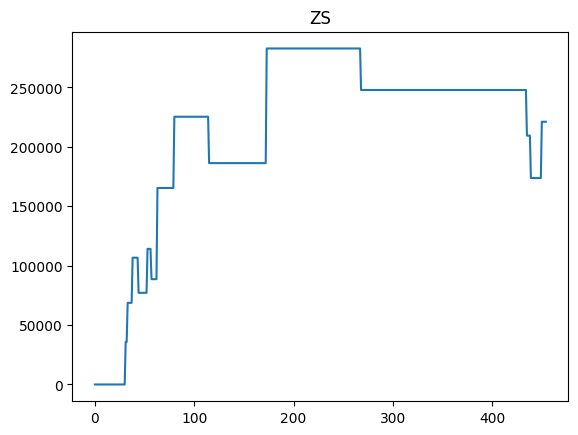

In [274]:
plt.plot(equity_c)
plt.title(ASSET)
plt.show()


In [275]:
trades_c

[{'type': 'long',
  'entry': 1092.265,
  'exit': 1099.4375,
  'pnl_points': 7.1724999999999,
  'pnl_usd': 35862.4999999995,
  'datetime_exit': Timestamp('2026-01-28 08:00:00+0000', tz='UTC')},
 {'type': 'long',
  'entry': 1098.265,
  'exit': 1104.8325,
  'pnl_points': 6.567499999999882,
  'pnl_usd': 32837.49999999941,
  'datetime_exit': Timestamp('2026-01-28 16:00:00+0000', tz='UTC')},
 {'type': 'long',
  'entry': 1101.765,
  'exit': 1109.3625,
  'pnl_points': 7.5974999999998545,
  'pnl_usd': 37987.49999999927,
  'datetime_exit': Timestamp('2026-01-29 16:00:00+0000', tz='UTC')},
 {'type': 'long',
  'entry': 1094.265,
  'exit': 1088.355,
  'pnl_points': -5.910000000000082,
  'pnl_usd': -29550.000000000407,
  'datetime_exit': Timestamp('2026-01-30 20:00:00+0000', tz='UTC')},
 {'type': 'long',
  'entry': 1088.015,
  'exit': 1095.415,
  'pnl_points': 7.399999999999864,
  'pnl_usd': 36999.999999999316,
  'datetime_exit': Timestamp('2026-02-03 16:00:00+0000', tz='UTC')},
 {'type': 'long',
  

In [276]:
import pandas as pd

trades_df = pd.DataFrame(trades_c)
trades_df["datetime_exit"] = pd.to_datetime(trades_df["datetime_exit"])
trades_df = trades_df.sort_values("datetime_exit").reset_index(drop=True)


In [277]:
trades_df["week"] = trades_df["datetime_exit"].dt.isocalendar().week
trades_df["year"] = trades_df["datetime_exit"].dt.isocalendar().year
weekly = trades_df.groupby(["year", "week"])["pnl_usd"].sum().reset_index()


In [278]:
def build_overlapping_blocks(series, block_size):
    n = len(series)

    if block_size > n:
        block_size = n  # máximo posible

    if block_size <= 0:
        raise ValueError("block_size inválido")

    blocks = []
    for start in range(n - block_size + 1):
        blocks.append(series[start:start + block_size])

    return blocks, block_size



In [279]:
import numpy as np

def monte_carlo_blocks(blocks, target_length, n_sims=1000):
    if len(blocks) == 0:
        raise ValueError("No hay bloques disponibles.")

    block_size = len(blocks[0])
    sims = []

    for _ in range(n_sims):
        pnl = []
        while len(pnl) < target_length:
            block = blocks[np.random.randint(0, len(blocks))]
            pnl.extend(block)
        sims.append(np.array(pnl[:target_length]))

    return np.array(sims)


In [280]:
weekly_pnl = weekly["pnl_usd"].values

blocks, block_size = build_overlapping_blocks(weekly_pnl, block_size=1)
print("block_size usado:", block_size)
print("n_blocks:", len(blocks))

mc = monte_carlo_blocks(blocks, len(weekly_pnl), n_sims=5000)


block_size usado: 1
n_blocks: 7


In [281]:
mc

array([[-26725. ,  88237.5,  96475. , ...,  59937.5, -34950. , -39025. ],
       [ 96475. ,  88237.5,  77137.5, ..., -39025. , -39025. , -26725. ],
       [ 88237.5,  88237.5, -39025. , ..., -39025. , -26725. ,  77137.5],
       ...,
       [ 77137.5, -39025. ,  59937.5, ...,  96475. , -34950. ,  88237.5],
       [ 88237.5, -34950. , -34950. , ...,  88237.5,  96475. , -34950. ],
       [ 59937.5, -34950. ,  88237.5, ...,  96475. , -39025. , -39025. ]],
      shape=(5000, 7))

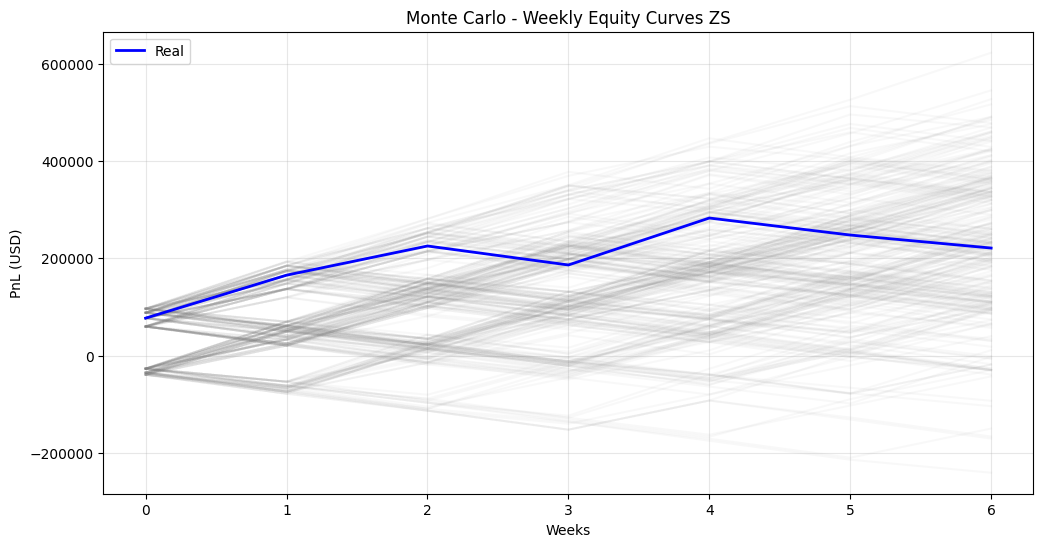

In [282]:
import matplotlib.pyplot as plt
import numpy as np

# equity real
real_equity = weekly_pnl.cumsum()

# equity simulada
mc_equity = mc.cumsum(axis=1)

plt.figure(figsize=(12,6))

# muchas curvas simuladas
for i in range(300):   # 300 para no saturar
    plt.plot(mc_equity[i], color="gray", alpha=0.05)

# curva real
plt.plot(real_equity, color="blue", linewidth=2, label="Real")

plt.title(f"Monte Carlo - Weekly Equity Curves {ASSET}")
plt.xlabel("Weeks")
plt.ylabel("PnL (USD)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()
